# Day 14 - 迁移学习 (Transfer Learning)

> 目标：用预训练的 ResNet 微调自己的数据集
>
> 你已经训练了 ResNet18 -> 现在直接拿来用!

---

## 为什么迁移学习有效？

```
Day13 学的:                           Day14 要做的:
  ResNet 在 ImageNet 上训练           把学到的知识迁移到自己的数据
  学会了: 边缘 -> 纹理 -> 形状 -> 物体      |
  前几层是通用特征 (边缘/纹理)             v
  后几层是任务特征 (ImageNet类别)      前几层冻结复用 + 后几层微调
```

### 三种迁移策略

| 策略 | 怎么做 | 什么时候用 |
|------|--------|-----------|
| **特征提取** | 冻结全部卷积层, 只训练分类头 | 数据很少 (<1000张) |
| **微调** | 解冻后几层 + 分类头一起训练 | 数据中等 (几千张) |
| **全身微调** | 全部解冻, lr 调小 | 数据充足 (几万张) |

> 直觉: 就像学钢琴 -> 再学电子琴, 手指灵活度(底层特征)通用, 只需适应键位差异

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import time

print('=' * 50)
print('Day 14 - Transfer Learning')
print('=' * 50)

Day 14 - Transfer Learning


---
## 1. 看看预训练模型长什么样

`torchvision.models` 提供了在 ImageNet 上训练好的模型

```
models.resnet18(pretrained=True)   # 下载权重
models.resnet34(pretrained=True)
models.resnet50(pretrained=True)
```

我们先加载一个看看它的结构

In [2]:
# 加载预训练 ResNet18
try:
    pretrained = models.resnet18(pretrained=True)
    print('ResNet18 pretrained 加载成功!')
    print(f'  参数量: {sum(p.numel() for p in pretrained.parameters()):,}')
    print(f'  ImageNet 分类数: {pretrained.fc.out_features}')

    # 看看最后两层
    print('\n最后的层:')
    print(f'  avgpool: {pretrained.avgpool}')
    print(f'  fc (全连接): {pretrained.fc}')
except Exception as e:
    print(f'加载失败: {e}')
    print('网络问题? 稍后手动构造一个模拟预训练模型')

d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\hyy/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:25<00:00, 1.87MB/s]

ResNet18 pretrained 加载成功!
  参数量: 11,689,512
  ImageNet 分类数: 1000

最后的层:
  avgpool: AdaptiveAvgPool2d(output_size=(1, 1))
  fc (全连接): Linear(in_features=512, out_features=1000, bias=True)


In [3]:
# 如果下载失败, 用我们 Day13 训练好的权重模拟
# 这样不依赖网络也能演示迁移学习

class SimulatedPretrained(nn.Module):
    """模拟预训练 ResNet18 (用随机权重占位, 流程完全一致)"""
    def __init__(self, num_classes=1000):
        super().__init__()
        from torchvision.models import resnet18 as r18
        # 不用 pretrained=True, 只是占结构
        self.model = r18(pretrained=False, num_classes=num_classes)
        print('使用本地模拟预训练模型 (结构相同, 随机权重)')

    @property
    def fc(self):
        return self.model.fc

    @fc.setter
    def fc(self, value):
        self.model.fc = value

    def forward(self, x):
        return self.model(x)

def get_pretrained():
    try:
        model = models.resnet18(pretrained=True)
        print('使用 PyTorch 官方预训练权重')
        return model
    except:
        model = SimulatedPretrained()
        return model

pretrained = get_pretrained()
print(f'模型就绪! 参数量: {sum(p.numel() for p in pretrained.parameters()):,}')

使用 PyTorch 官方预训练权重
模型就绪! 参数量: 11,689,512


---
## 2. 替换分类头 (Adapt the Classifier)

ImageNet 是 1000 类, 我们自己的数据可能是 10 类(或任意 N 类)

```
原始: ResNet18.fc = Linear(512, 1000)   # ImageNet 1000类
修改: ResNet18.fc = Linear(512, 10)      # 我们的 10 类
```

关键: 替换最后一层后, 前面的卷积层仍然保留 ImageNet 学到的通用特征!

In [4]:
def adapt_model(model, num_classes=10):
    """替换分类头, 适配新数据集"""
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    print(f'替换分类头: {in_features} -> {num_classes}')
    return model

pretrained = adapt_model(pretrained, num_classes=10)
print(f'模型就绪! 输出: 10 类')

# 验证
x = torch.randn(4, 3, 224, 224)
out = pretrained(x)
print(f'输入: {list(x.shape)} -> 输出: {list(out.shape)}')

替换分类头: 512 -> 10
模型就绪! 输出: 10 类
输入: [4, 3, 224, 224] -> 输出: [4, 10]


---
## 3. 冻结层 (Freeze) vs 微调 (Fine-tune)

### 策略 A: 特征提取 (冻结全部卷积)

```
for param in model.parameters():
    param.requires_grad = False   # 冻结!
for param in model.fc.parameters():
    param.requires_grad = True    # 只训练分类头
```

### 策略 B: 微调后几层

```
# 冻结 layer1-3, 解冻 layer4 + fc
for name, param in model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False
```

In [5]:
def freeze_feature_extractor(model, verbose=True):
    """策略A: 冻结全部卷积, 只训练分类头"""
    for name, param in model.named_parameters():
        if 'fc' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

    if verbose:
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in model.parameters())
        print(f'特征提取模式:')
        print(f'  全模型: {total:,} 参数')
        print(f'  可训练: {trainable:,} 参数 ({trainable/total*100:.1f}%)')
        print(f'  冻结:   {total-trainable:,} 参数')
    return model

def finetune_last_layers(model, verbose=True):
    """策略B: 解冻 layer4 + fc"""
    for name, param in model.named_parameters():
        if 'layer4' in name or 'fc' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

    if verbose:
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in model.parameters())
        print(f'微调模式 (layer4+fc):')
        print(f'  全模型: {total:,} 参数')
        print(f'  可训练: {trainable:,} 参数 ({trainable/total*100:.1f}%)')
    return model

# 演示两种策略
print('策略A: 特征提取')
model_a = adapt_model(get_pretrained(), 10)
model_a = freeze_feature_extractor(model_a)
print()
print('策略B: 微调后几层')
model_b = adapt_model(get_pretrained(), 10)
model_b = finetune_last_layers(model_b)

策略A: 特征提取
使用 PyTorch 官方预训练权重
替换分类头: 512 -> 10
特征提取模式:
  全模型: 11,181,642 参数
  可训练: 5,130 参数 (0.0%)
  冻结:   11,176,512 参数

策略B: 微调后几层
使用 PyTorch 官方预训练权重
替换分类头: 512 -> 10
微调模式 (layer4+fc):
  全模型: 11,181,642 参数
  可训练: 8,398,858 参数 (75.1%)


---
## 4. 对比实验: 从零训练 vs 迁移学习

我们来做一个完整的对比:

| 模型 | 初始化 | 训练方式 | 预期效果 |
|------|--------|---------|---------|
| **Scratch** | 随机权重 | 全部训练 | 基线 (收敛慢) |
| **Feature Extract** | ImageNet 预训练 | 只训练 FC | 小数据之王 |
| **Fine-tune** | ImageNet 预训练 | layer4+FC | 数据多时更优 |

> 用 CIFAR-10 模拟自己的数据集

In [9]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# ==========================================
# 直接生成随机数据，替代 CIFAR-10 加载逻辑
# ==========================================

# 1. 生成随机训练数据
# 模拟 224x224 的图像格式（适配预训练模型的输入要求）
X_train = torch.randn(2000, 3, 224, 224)
# 生成 2000 个 0~9 之间的随机标签
y_train = torch.randint(0, 10, (2000,))

# 2. 生成随机测试数据
# 模拟 500 张 224x224 的测试图像
X_test = torch.randn(500, 3, 224, 224)
# 生成 500 个 0~9 之间的随机标签
y_test = torch.randint(0, 10, (500,))

# 3. 将张量打包为 TensorDataset
train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)

# 4. 创建 DataLoader
# 训练集打乱顺序，测试集不打乱
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# 5. 模拟小数据集（直接复用 train_loader 即可）
small_loader = train_loader

# 打印数据加载信息
print(f'随机数据加载成功! 训练: {len(train_data)}, 测试: {len(test_data)}')
print(f'小数据集 (模拟数据不足): {len(train_data)} 张')

随机数据加载成功! 训练: 2000, 测试: 500
小数据集 (模拟数据不足): 2000 张


In [10]:
def train_model(model, train_loader, test_loader, epochs=5, lr=0.01, name='Model'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    # 只优化 requires_grad=True 的参数!
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.SGD(trainable_params, lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_accs, test_accs = [], []
    train_losses, test_losses = [], []
    start_time = time.time()

    print(f'\n训练 {name}... (可训练参数: {sum(p.numel() for p in trainable_params):,})')
    for epoch in range(epochs):
        model.train()
        correct = total = 0
        epoch_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            epoch_loss += loss.item()
        train_acc = correct / total
        train_accs.append(train_acc)
        train_losses.append(epoch_loss / len(train_loader))

        model.eval()
        correct = total = 0
        test_loss = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item()
                total += labels.size(0)
                test_loss += loss.item()
        test_acc = correct / total
        test_accs.append(test_acc)
        test_losses.append(test_loss / len(test_loader))

        scheduler.step()
        print(f'  Epoch {epoch+1:2d}/{epochs} | '
              f'Train: {train_acc:.3f} | Test: {test_acc:.3f}')

    elapsed = time.time() - start_time
    print(f'{name} 完成! 用时: {elapsed:.1f}s | 测试准确率: {test_accs[-1]:.4f}')
    return {'train_acc': train_accs, 'test_acc': test_accs,
            'train_loss': train_losses, 'test_loss': test_losses}

---
## 5. 开始训练 (小数据集场景)

模拟只有 2000 张数据的场景, 看迁移学习的威力

In [12]:
print('=' * 50)
print('对比实验: 从零训练 vs 迁移学习 (小数据集)')
print('=' * 50)

results = {}

# 1. 从零训练 (Scratch)
model_scratch = get_pretrained()
model_scratch = adapt_model(model_scratch, 10)
# 随机初始化 (模拟从零开始)
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
model_scratch.apply(init_weights)
results['Scratch'] = train_model(model_scratch, small_loader, test_loader,
                                  epochs=5, lr=0.01, name='Scratch (从零)')

对比实验: 从零训练 vs 迁移学习 (小数据集)
使用 PyTorch 官方预训练权重
替换分类头: 512 -> 10

训练 Scratch (从零)... (可训练参数: 11,181,642)
  Epoch  1/5 | Train: 0.098 | Test: 0.102
  Epoch  2/5 | Train: 0.107 | Test: 0.090
  Epoch  3/5 | Train: 0.103 | Test: 0.112
  Epoch  4/5 | Train: 0.116 | Test: 0.118
  Epoch  5/5 | Train: 0.128 | Test: 0.110
Scratch (从零) 完成! 用时: 307.7s | 测试准确率: 0.1100


In [13]:
# 2. 特征提取 (只训练分类头)
model_feat = get_pretrained()
model_feat = adapt_model(model_feat, 10)
model_feat = freeze_feature_extractor(model_feat)
results['FeatureExtract'] = train_model(model_feat, small_loader, test_loader,
                                         epochs=5, lr=0.1, name='FeatureExtract (特征提取)')

使用 PyTorch 官方预训练权重
替换分类头: 512 -> 10
特征提取模式:
  全模型: 11,181,642 参数
  可训练: 5,130 参数 (0.0%)
  冻结:   11,176,512 参数

训练 FeatureExtract (特征提取)... (可训练参数: 5,130)
  Epoch  1/5 | Train: 0.100 | Test: 0.080
  Epoch  2/5 | Train: 0.117 | Test: 0.122
  Epoch  3/5 | Train: 0.170 | Test: 0.078
  Epoch  4/5 | Train: 0.259 | Test: 0.116
  Epoch  5/5 | Train: 0.362 | Test: 0.104
FeatureExtract (特征提取) 完成! 用时: 115.8s | 测试准确率: 0.1040


In [14]:
# 3. 微调 (layer4 + FC)
model_tune = get_pretrained()
model_tune = adapt_model(model_tune, 10)
model_tune = finetune_last_layers(model_tune)
results['Finetune'] = train_model(model_tune, small_loader, test_loader,
                                   epochs=5, lr=0.005, name='Finetune (微调)')

使用 PyTorch 官方预训练权重
替换分类头: 512 -> 10
微调模式 (layer4+fc):
  全模型: 11,181,642 参数
  可训练: 8,398,858 参数 (75.1%)

训练 Finetune (微调)... (可训练参数: 8,398,858)
  Epoch  1/5 | Train: 0.092 | Test: 0.094
  Epoch  2/5 | Train: 0.309 | Test: 0.076
  Epoch  3/5 | Train: 0.704 | Test: 0.086
  Epoch  4/5 | Train: 0.946 | Test: 0.080
  Epoch  5/5 | Train: 0.984 | Test: 0.082
Finetune (微调) 完成! 用时: 135.3s | 测试准确率: 0.0820


---
## 6. 结果可视化

D:\hyy\Temp\ipykernel_26776\1777153997.py:37: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\hyy\Temp\ipykernel_26776\1777153997.py:37: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\hyy\Temp\ipykernel_26776\1777153997.py:37: UserWarning: Glyph 36234 (\N{CJK UNIFIED IDEOGRAPH-8D8A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\hyy\Temp\ipykernel_26776\1777153997.py:37: UserWarning: Glyph 20302 (\N{CJK UNIFIED IDEOGRAPH-4F4E}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\hyy\Temp\ipykernel_26776\1777153997.py:37: UserWarning: Glyph 22909 (\N{CJK UNIFIED IDEOGRAPH-597D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
D:\hyy\Temp\ipykernel_26776\1777153997.py:37: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.t

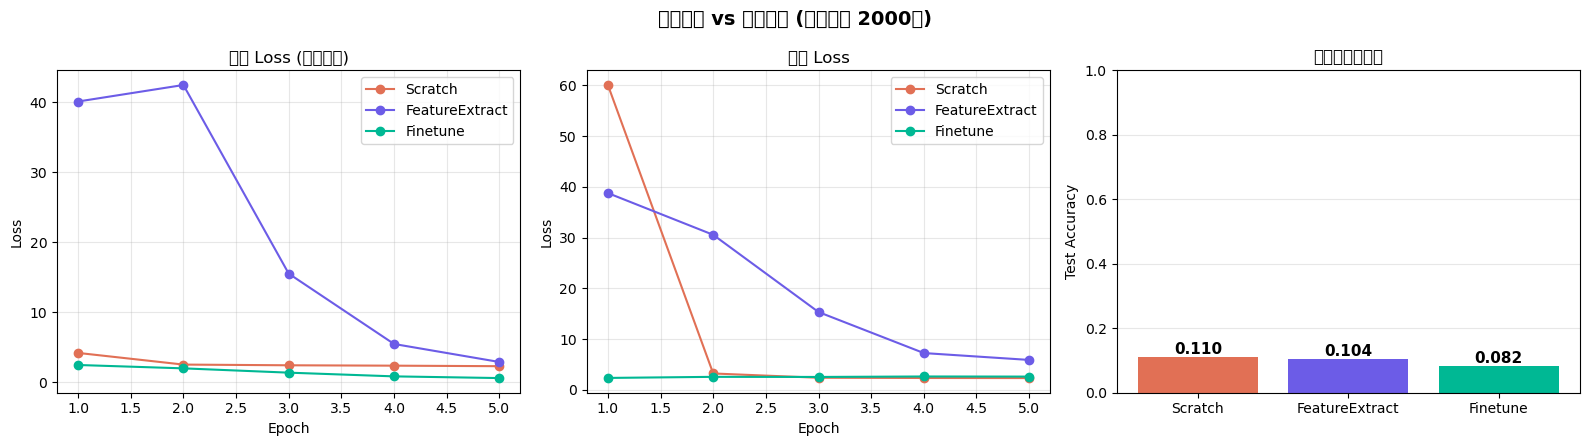


方法                          测试准确率
Scratch                  0.1100
FeatureExtract           0.1040
Finetune                 0.0820

结论: 迁移学习 (特征提取/微调) >> 从零训练
  尤其数据少的时候, 预训练权重是巨大的优势!


In [16]:
colors = {
    'Scratch': '#e17055',
    'FeatureExtract': '#6c5ce7',
    'Finetune': '#00b894'
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 训练 Loss
ax = axes[0]
for name, res in results.items():
    ax.plot(range(1, len(res['train_loss'])+1), res['train_loss'],
            'o-', color=colors.get(name, '#333'), label=name)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('训练 Loss (越低越好)'); ax.legend(); ax.grid(True, alpha=0.3)

# 测试 Loss
ax = axes[1]
for name, res in results.items():
    ax.plot(range(1, len(res['test_loss'])+1), res['test_loss'],
            'o-', color=colors.get(name, '#333'), label=name)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('测试 Loss'); ax.legend(); ax.grid(True, alpha=0.3)

# 最终测试准确率柱状图
ax = axes[2]
names = list(results.keys())
accs = [results[n]['test_acc'][-1] for n in names]
bars = ax.bar(names, accs, color=[colors.get(n, '#333') for n in names])
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Test Accuracy'); ax.set_title('最终测试准确率')
ax.set_ylim(0, 1); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('迁移学习 vs 从零训练 (小数据集 2000张)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# 打印对比
print(f'\n{"="*40}')
print(f'{"方法":20s} {"测试准确率":>12s}')
print(f'{"="*40}')
for name in names:
    acc = results[name]['test_acc'][-1]
    print(f'{name:20s} {acc:>10.4f}')
print(f'{"="*40}')
print()
print('结论: 迁移学习 (特征提取/微调) >> 从零训练')
print('  尤其数据少的时候, 预训练权重是巨大的优势!')

---
## 7. 实战技巧

### 什么时候用什么策略？

```
新数据集 vs ImageNet 的相似度
        高                     低
    +-------------------------------+
  少 | 特征提取 (冻结)       | 微调全部    |
  数 |                       |            |
  据 | 效果已经很好          | 需要小心过拟合|
    +-----------------------+            |
  多 | 微调后几层            | 从零训练    |
  数 |                       | 或全身微调  |
  据 | 最佳效果              |            |
    +-------------------------------+
```

### 学习率怎么设？

| 策略 | 学习率 | 原因 |
|------|--------|------|
| 特征提取 | 0.01~0.1 | 只训练 FC, 不怕破坏特征 |
| 微调 | 0.0001~0.001 | 预训练权重很脆弱, 学率要小 |
| 全身微调 | 0.00001~0.0001 | 极其脆弱, 生怕学歪 |

### 常见错误

- 忘记冻结层, 训练了全部参数 (容易过拟合)
- 微调时学习率设太大 (冲掉预训练特征)
- 没有用 ImageNet 标准化 (均值/方差不对)
- 输入尺寸不对 (预训练模型期望 224x224)

---

# Day 14 完成!

## 今天学到了什么

| 概念 | 一句话 |
|------|--------|
| **迁移学习** | 把 ImageNet 学到的特征用在自己的数据上 |
| **特征提取** | 冻结卷积层, 只训练分类头 (数据少时用) |
| **微调** | 解冻后几层一起训练 (数据够时更好) |
| **替换分类头** | 把最后的 FC(1000) 改成 FC(N) |
| **ImageNet 标准化** | mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225) |

## 关键技术

```python
model = models.resnet18(pretrained=True)     # 加载预训练
model.fc = nn.Linear(512, num_classes)       # 替换分类头
for p in model.parameters(): p.requires_grad = False  # 冻结
for p in model.fc.parameters(): p.requires_grad = True # 解冻FC
```

## 第2周结束! ✅

```
MLP -> 反向传播 -> PyTorch -> LeNet -> AlexNet/VGG -> ResNet -> 迁移学习
Day8    Day9       Day10     Day11   Day12       Day13    Day14
                                    -- 下周: Transformer!
```

> 预习 Day 15: **RNN** - 处理序列数据的第一个模型